In [7]:
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np


def validate_results(results):
    for name, folds in results.items():
        for fold, ns in folds.items():
            for n, sims in ns.items():
                for sim, content in sims.items():
                    assert "true" in content
                    assert "pred" in content
    print("Result schema validated")


with open("./results/benchmarks/convnext_lab.pkl", "rb") as f:
    results = pickle.load(f)

validate_results(results)

Result schema validated


In [ ]:
def infer_axes(results):
    name = next(iter(results))
    fold = next(iter(results[name]))
    n = next(iter(results[name][fold]))
    sim = next(iter(results[name][fold][n]))
    k = next(iter(results[name][fold][n][sim]["pred"]))
    setup = next(iter(results[name][fold][n][sim]["pred"][k]))
    return name, fold, n, sim, k, setup


name0, fold0, n0, sim0, k0, setup0 = infer_axes(results)
NAMES = list(results.keys())
FOLDS = list(results[name0].keys())
N = list(results[name0][fold0].keys())
SIMS = list(results[name0][fold0][n0].keys())
K = list(results[name0][fold0][n0][sim0]["pred"].keys())
SETUPS = list(results[name0][fold0][n0][sim0]["pred"][k0].keys())


def aggregate_metrics(results, coder, name, folds, sims, setups, n, k):
    metrics = {setup: [] for setup in setups}

    for fold in folds:
        sub = results[name][fold][n]
        for sim in sims:
            # collect all labels
            labels = [sub[sim]["true"]]
            for setup in setups:
                labels.append(sub[sim]["pred"][k][setup])

            all_labels = np.unique(np.concatenate(labels))
            coder = LabelEncoder().fit(all_labels)

            # combine + deduplicate
            true = coder.transform(sub[sim]["true"])
            for setup in setups:
                pred = coder.transform(sub[sim]["pred"][k][setup])
                acc = accuracy_score(true, pred)
                prec, rec, f1, _ = precision_recall_fscore_support(true, pred, average="macro", warn_for=[])
                metrics[setup].append((acc, prec, rec, f1))

    return {
        setup: {
            "mean": np.mean(vals, axis=0),
            "std": np.std(vals, axis=0),
        }
        for setup, vals in metrics.items()
    }


def print_markdown_table(stats):
    print("| Setup | Acc | Prec | Rec | F1 |")
    print("|---|---|---|---|---|")
    for setup, s in stats.items():
        row = [
            f"{m * 100:.2f} ± {d * 100:.2f}" 
            for m, d in zip(s["mean"], s["std"])
        ]
        print(f"| {setup.replace(' - ', ' | ')} | " + " | ".join(row) + " |")


def print_latex_acc(stats):
    print("% LaTeX table for accuracy only")
    for setup, s in stats.items():
        acc_m, acc_s = s["mean"][0] * 100, s["std"][0] * 100
        g, q = (setup.split(" - ") + [""])[:2]
        print(f"{g} & {q} & {acc_m:.2f}$\\pm${acc_s:.2f}\\% \\\\")

In [40]:
show_latex = False
n = 16  
k = 3
folds = FOLDS[:]    # <- give fold(s) as a list
sims = SIMS[:]      # <- give sim(s) as a list
setups = SETUPS[:]  # <- give sim(s) as a list
metrics = {}

# Define readable metric names for the header
metric_names = ["Acc", "Prec", "Rec", "F1"]

for name in NAMES:
    print(f"### {name}\n")

    stats = aggregate_metrics(
        results=results,
        coder=coder,
        name=name,
        folds=folds,
        sims=sims,
        setups=setups,
        n=n,
        k=k,
    )

    metrics[name] = stats
    # Markdown table
    print_markdown_table(stats)
    print()

    # Optional LaTeX
    if show_latex:
        print_latex_acc(stats)
        print()


### convnext_femto_cnn_clip_512_LAB

| Setup | Acc | Prec | Rec | F1 |
|---|---|---|---|---|
| I | I | 60.44 ± 2.36 | 35.28 ± 1.00 | 47.44 ± 1.18 | 35.37 ± 0.99 |
| I | P | 21.67 ± 4.43 | 14.68 ± 1.73 | 15.90 ± 1.68 | 10.43 ± 1.10 |
| I | I+P | 60.10 ± 3.28 | 35.97 ± 0.96 | 47.64 ± 0.98 | 35.71 ± 0.86 |
| P | I | 31.55 ± 5.34 | 14.69 ± 1.05 | 16.99 ± 1.16 | 12.05 ± 1.35 |
| P | P | 61.43 ± 2.21 | 32.43 ± 1.32 | 42.61 ± 1.05 | 32.18 ± 1.10 |
| P | I+P | 62.26 ± 2.04 | 32.76 ± 1.41 | 43.22 ± 1.10 | 32.62 ± 1.16 |
| I+P | I | 60.40 ± 2.35 | 35.03 ± 0.91 | 47.22 ± 0.95 | 35.18 ± 0.87 |
| I+P | P | 61.42 ± 2.22 | 32.47 ± 1.28 | 42.63 ± 1.02 | 32.22 ± 1.07 |
| I+P | I+P | 67.73 ± 1.83 | 38.69 ± 1.48 | 49.74 ± 1.26 | 38.40 ± 1.29 |

### convnext_femto_transformer_clip_512_LAB

| Setup | Acc | Prec | Rec | F1 |
|---|---|---|---|---|
| I | I | 64.12 ± 3.18 | 36.14 ± 0.99 | 46.67 ± 1.56 | 35.94 ± 0.91 |
| I | P | 18.94 ± 5.43 | 13.07 ± 3.26 | 11.93 ± 2.52 | 8.18 ± 2.15 |
| I | I+P | 63.96 ± 3.95

### Visualize mean and std for each N

convnext_femto_transformer_clip_512_LAB folds: 100%|██████████| 5/5 [00:00<00:00, 12.35it/s]


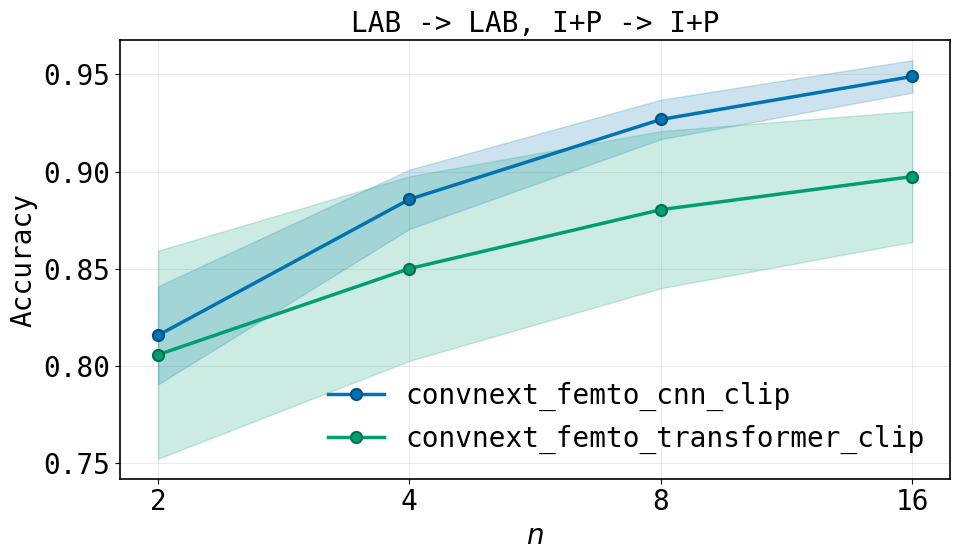

In [5]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configs
k = 3
n_vals = N[:]
folds = FOLDS[:] 
sims = SIMS[:]  
setup = "I+P - I+P"  # which setup to plot

# Label size
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans Mono",
        "font.size": 20,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        # 'legend.fontsize': 20,
        "figure.titlesize": 20,
        "axes.linewidth": 1.2,
    }
)

def darker(color, factor=0.7):
    """Return a darker shade of a Matplotlib-compatible color."""
    import matplotlib.colors as mcolors

    rgb = np.array(mcolors.to_rgb(color))
    return np.clip(rgb * factor, 0, 1)

# Adapted colourblind palette
colorblind = ["#0173B2", "#029E73", "#D55E00", "#CC78BC", "#ECE133", "#949494"]

# Create figures
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(True, which="major", linestyle="-", linewidth=0.75, alpha=0.25)
ax.set_axisbelow(True)

# Loop over models
for idx, name in enumerate(NAMES):
    color = colorblind[idx % len(colorblind)]
    edge_color = darker(color)

    accs = {n: [] for n in n_vals}
    for fold in tqdm(folds, desc=f"{name} folds"):
        for n in n_vals:
            sub = results[name][fold][n]
            for sim in sims:
                true = coder.transform(sub[sim]["true"])
                pred = coder.transform(sub[sim]["pred"][k][setup])
                acc = accuracy_score(true, pred)
                accs[n].append(acc)

    # Compute mean ± std per n
    means = np.array([np.mean(accs[n]) for n in n_vals])
    stds = np.array([np.std(accs[n]) for n in n_vals])

    # Plot
    ax.plot(
        n_vals,
        means,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=8,
        markeredgewidth=1.5,
        markeredgecolor=edge_color,
        label=name,
        zorder=3,
    )

    ax.fill_between(n_vals, means - stds, means + stds, color=color, alpha=0.2, zorder=2)

# Set axis and labels
ax.set_xlabel(r"$n$")
ax.set_ylabel("Accuracy")
ax.set_xscale("log")
ax.set_xticks(n_vals)
ax.set_xticklabels(n_vals)
ax.minorticks_off()

# Add legend
handles, labels = ax.get_legend_handles_labels()

labels2 = ["_".join(label.split("_")[:4]) for label in labels]

ax.legend(
    handles,
    labels2,
    loc="lower right",
    ncol=1,
    frameon=False,
)

# Show and save (optional)
plt.title("LAB -> LAB, I+P -> I+P")
plt.tight_layout()
plt.savefig("./results/figures/example_results2.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()
